In [1]:
import tensorflow as tf
import cv2
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
import time
import os

In [2]:
import homography_utility as h

In [3]:
patch_size = h.patch_size
kernel_size = h.patch_size
image_size = h.image_size
descriptor_dimension = h.descriptor_dimension

max_rotation = h.max_rotation
rotation_multiple = h.rotation_multiple
max_skew = h.max_skew

margin = h.margin
threshold = h.threshold
learning_rate = h.learning_rate
optimizer = h.optimizer
cos_sim = h.cos_sim
batch_size = h.batch_size
epochs = h.epochs
num_filters = h.num_filters
model_path = h.backup_model_path
backup_model_path = h.backup_model_path

In [4]:
#get a random image and get all keypoint and get 32 X 32 pixels around it
dir ='real_images'
list_of_images = os.listdir(dir)
image_name=".DS_Store"
while(image_name == ".DS_Store"):
    image_name = np.random.choice(list_of_images)

print('chosen image is' , image_name)
image_path  = os.path.join(dir,image_name)
print('chosen image path is' , image_path)



chosen image is 761.png
chosen image path is real_images\761.png


In [5]:
#load the image and get all keypoints
image  = cv2.imread(image_path)
image = cv2.resize(image, (image_size, image_size))
orb= cv2.ORB_create(100)
kp = orb.detect(image)


In [6]:
#select a keypoint that has atleast patch_size/2 pixels around it
got = False
x=0
y=0
k=0
while(not got):
    k=np.random.choice(kp)
    if(k.pt[0] >patch_size/2 and k.pt[1] >patch_size/2 and k.pt[1]<image_size-(patch_size/2 )and k.pt[0]<image_size-(patch_size/2)):
        got=True

print(k.pt)

(52.0, 95.0)


In [7]:
#draw the point on image and get rotated images
transformed_image = cv2.warpPerspective(image, h.get_random_homography_matrix(True), (image_size, image_size))
cv2.circle(image,(int(k.pt[0]),int(k.pt[1])),3,(255,0,0))



array([[[19, 20, 28],
        [18, 23, 28],
        [22, 24, 31],
        ...,
        [ 4,  5,  4],
        [ 5,  4,  3],
        [ 2,  4,  2]],

       [[21, 23, 30],
        [23, 24, 28],
        [21, 25, 30],
        ...,
        [ 2,  6,  3],
        [ 6,  7,  5],
        [ 6,  6,  2]],

       [[21, 23, 29],
        [23, 23, 32],
        [23, 24, 30],
        ...,
        [ 6,  6,  9],
        [ 6,  6,  5],
        [ 4,  6,  6]],

       ...,

       [[ 9, 11, 15],
        [ 9, 11, 14],
        [ 8, 12, 16],
        ...,
        [10, 13, 16],
        [ 8, 13, 13],
        [ 8, 11, 14]],

       [[ 7, 10, 13],
        [ 9, 10, 14],
        [ 7, 10, 14],
        ...,
        [10, 12, 18],
        [ 8, 13, 15],
        [ 8, 11, 14]],

       [[ 8, 11, 15],
        [ 9, 12, 13],
        [ 8, 11, 14],
        ...,
        [ 8, 12, 16],
        [ 8, 11, 16],
        [ 7, 11, 11]]], dtype=uint8)

In [8]:
#get all keypoints in random rotation 
kp_random  = orb.detect(transformed_image)


In [9]:
img =image
img_t=transformed_image

image = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)
transformed_image = cv2.cvtColor(transformed_image,cv2.COLOR_RGB2GRAY)

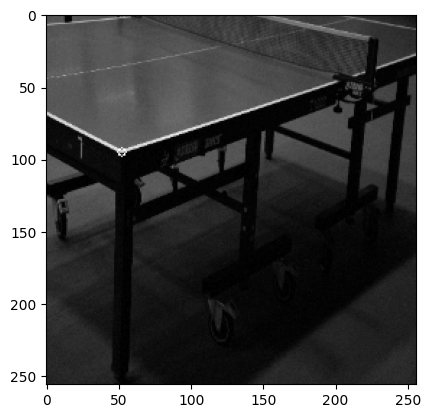

In [10]:
#convert ll to greyscale

plt.imshow(image,cmap='gray')

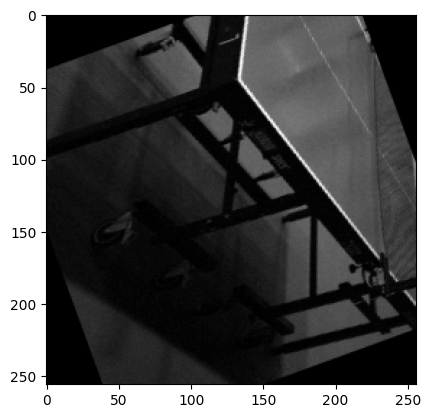

In [11]:
plt.imshow(transformed_image,cmap='gray')

In [12]:
#create a function that will describe a patch around a keypoint 
filters = np.load('learned_filters/learned_filters_chnnel_8.npy')
print('filters are ',filters.shape)
def describe_patch(image, kp):
    patch = tf.convert_to_tensor(image[int(kp.pt[1]-patch_size/2):int(kp.pt[1]+patch_size/2), int(kp.pt[0]-patch_size/2):int(kp.pt[0]+patch_size/2)],dtype=tf.double)
    activated_filer = tf.keras.activations.tanh(tf.convert_to_tensor(filters))
    # print('activated_filer is ',activated_filer.shape)
    patch = tf.repeat(tf.expand_dims(patch,-1),num_filters,-1)
    operated_patch = tf.multiply(activated_filer,patch)
    final_vector = tf.reduce_mean(operated_patch,[0,1])
    # print('final vector is',final_vector.shape)
    return  final_vector

filters are  (64, 64, 8)


In [13]:
desc_original_kp = describe_patch(image,k)
print(desc_original_kp)

tf.Tensor(
[ 0.15266731 -0.11235298 -0.06209046  0.01466739 -0.02592265  0.07424001
 -0.03152162  0.28133256], shape=(8,), dtype=float64)


In [14]:
#describe every kp in transformed image and print the best match 
max_pt =kp_random[0]
max_similarity = -cos_sim(desc_original_kp,describe_patch(transformed_image,max_pt))
second_max_similarity = max_similarity


for t_kp in kp_random:
    desc_t_kp = describe_patch(transformed_image,t_kp)
    similarity = -cos_sim(desc_original_kp,desc_t_kp)
    if(similarity > max_similarity):
        second_max_similarity = max_similarity
        max_similarity = similarity
        max_pt = t_kp
   

In [15]:
img=cv2.circle(img,(int(k.pt[0]),int(k.pt[1])),6,(255,0,0),-1)
img_t=cv2.circle(img_t,(int(max_pt.pt[0]),int(max_pt.pt[1])),6,(255,0,0),-1)
print('done')


done


max similarity 0.6467636227607727
second max similarity 0.6208154559135437
relative similarity 0.9598799840713571


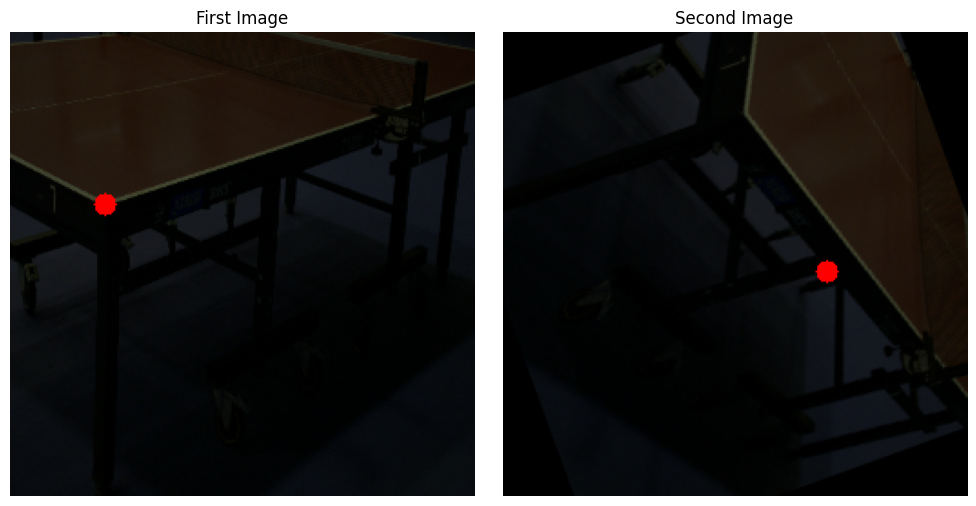

In [16]:
print("max similarity", max_similarity.numpy())
print("second max similarity", second_max_similarity.numpy())
print("relative similarity", (second_max_similarity/max_similarity).numpy())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title('First Image')
axes[0].axis('off')

# Plot the second image
axes[1].imshow(img_t)
axes[1].set_title('Second Image')
axes[1].axis('off')

# Display the plot
plt.tight_layout()
plt.show()
